# Groups

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action='ignore',category=np.VisibleDeprecationWarning)

## Lecture 10 ##

## Prediction ##

In [3]:
families = Table.read_table('family_heights.csv')
families

family,father,mother,child,children,order,child m/f
1,78.5,67,73.2,4,1,male
1,78.5,67,69.2,4,2,female
1,78.5,67,69,4,3,female
1,78.5,67,69,4,4,female
2,75.5,66.5,73.5,4,1,male
2,75.5,66.5,72.5,4,2,male
2,75.5,66.5,65.5,4,3,female
2,75.5,66.5,65.5,4,4,female
3,75,64,71,2,1,male
3,75,64,68,2,2,female


In [4]:
parent_avgs = (families.column('father') + families.column('mother'))/2

In [5]:
heights = Table().with_columns(
    'Parent Average', parent_avgs,
    'Child', families.column('child'), # At adulthood
    'M/F', families.column('child m/f')
)
heights

Parent Average,Child,M/F
72.75,73.2,male
72.75,69.2,female
72.75,69,female
72.75,69,female
71,73.5,male
71,72.5,male
71,65.5,female
71,65.5,female
69.5,71,male
69.5,68,female


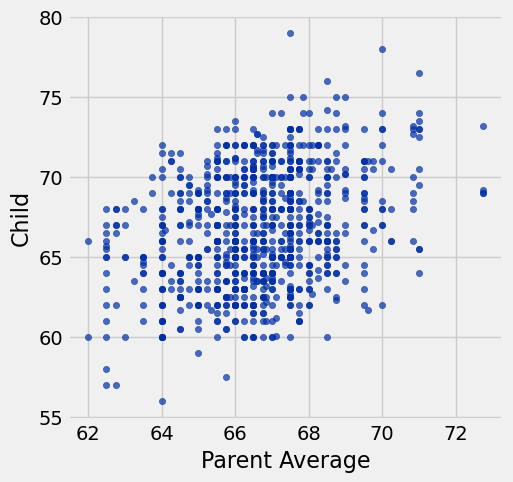

In [6]:
heights.scatter('Parent Average', 'Child')

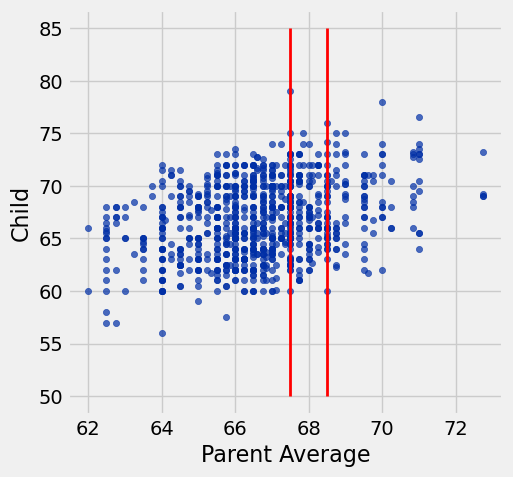

In [7]:
heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2);

In [9]:
nearby = heights.where('Parent Average', are.between(67.5, 68.5))
nearby_mean = np.average(nearby.column('Child'))
nearby_mean

67.620000000000005

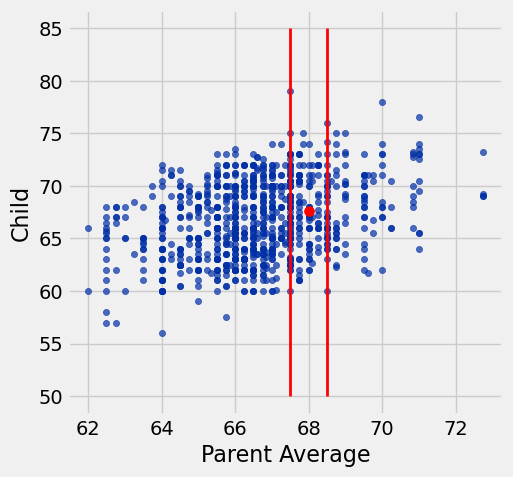

In [10]:
heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plots.scatter(68, nearby_mean, color='red', s=50);

In [11]:
def predict(h):  # h is the average height of the parents, such as 68
    nearby = heights.where('Parent Average', are.between(h - 1/2, h + 1/2))
    return np.average(nearby.column('Child'))

In [12]:
predict(68)

67.620000000000005

In [13]:
predict(70)

68.561904761904756

In [14]:
predict(73)

70.099999999999994

In [15]:
predicted_heights = heights.apply(predict, 'Parent Average')

In [17]:
heights = heights.with_column('Prediction', predicted_heights)
heights

Parent Average,Child,M/F,Prediction
72.75,73.2,male,70.1
72.75,69.2,female,70.1
72.75,69,female,70.1
72.75,69,female,70.1
71,73.5,male,70.4158
71,72.5,male,70.4158
71,65.5,female,70.4158
71,65.5,female,70.4158
69.5,71,male,68.5025
69.5,68,female,68.5025


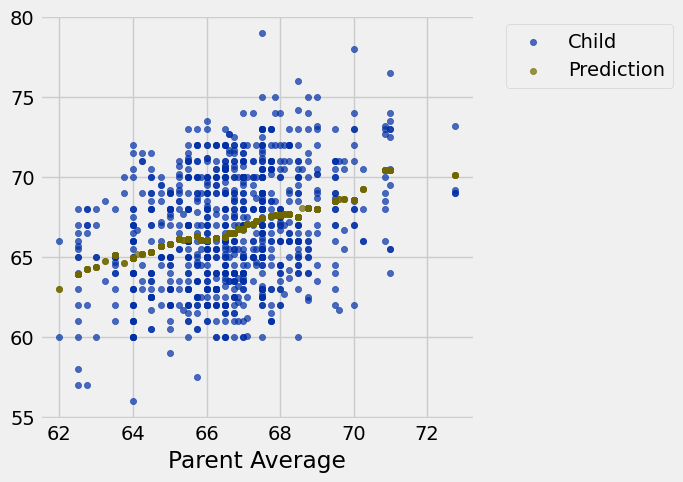

In [18]:
heights.select('Parent Average', 'Child', 'Prediction').scatter('Parent Average')

## Prediction Accuracy ##

In [21]:
pred_errs = heights.column('Prediction') - heights.column('Child')
heights = heights.with_column('errors',pred_errs)
heights

Parent Average,Child,M/F,Prediction,errors
72.75,73.2,male,70.1,-3.1
72.75,69.2,female,70.1,0.9
72.75,69,female,70.1,1.1
72.75,69,female,70.1,1.1
71,73.5,male,70.4158,-3.08421
71,72.5,male,70.4158,-2.08421
71,65.5,female,70.4158,4.91579
71,65.5,female,70.4158,4.91579
69.5,71,male,68.5025,-2.4975
69.5,68,female,68.5025,0.5025


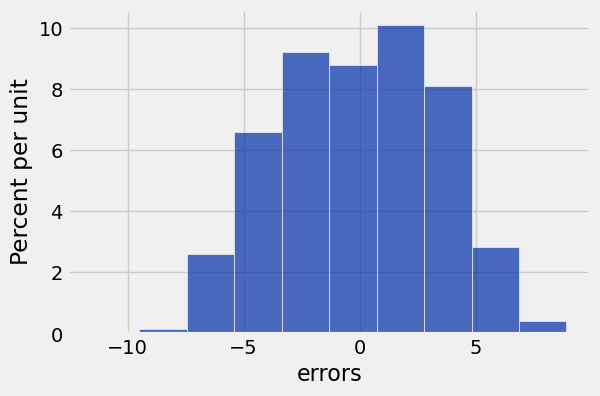

In [22]:
heights.hist('errors')

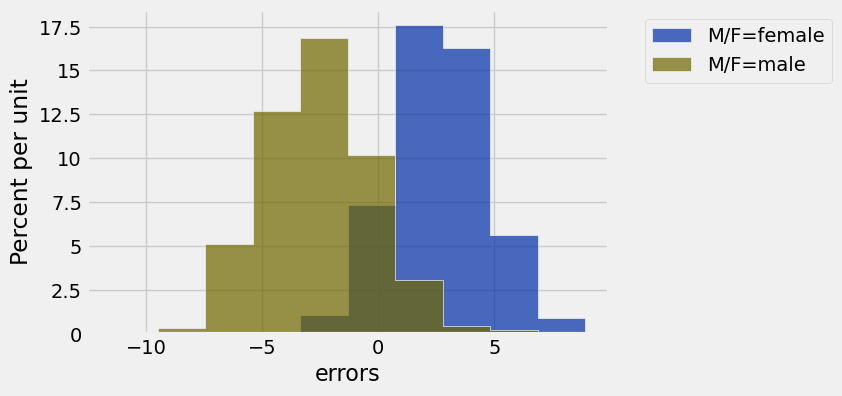

In [24]:
heights.hist('errors', group='M/F')

## Discussion Question

In [25]:
def predict_smarter(h, s):
    nearby = heights.where('Parent Average', are.between(h - 1/2, h + 1/2))
    nearby_same_mf = nearby.where('M/F', s)
    return np.average(nearby_same_mf.column('Child'))

In [26]:
predict_smarter(68, 'female')

64.983516483516482

In [27]:
predict_smarter(68, 'male')

70.172340425531914

In [29]:
heights.apply(predict_smarter, "Parent Average", "M/F")

array([ 73.2       ,  69.06666667,  69.06666667,  69.06666667,
        73.48888889,  73.48888889,  67.65      ,  67.65      ,
        70.79545455,  65.7       ,  70.79545455,  70.79545455,
        65.7       ,  65.7       ,  65.7       ,  69.25322581,
        69.25322581,  69.25322581,  63.59495798,  63.59495798,
        63.59495798,  67.65      ,  73.48888889,  73.48888889,
        73.48888889,  73.48888889,  67.65      ,  67.65      ,
        66.82      ,  66.82      ,  66.82      ,  66.82      ,
        65.75882353,  70.17234043,  70.17234043,  64.98351648,
        64.98351648,  64.98351648,  64.98351648,  64.98351648,
        64.98351648,  64.67788462,  71.00952381,  66.11428571,
        71.00952381,  71.00952381,  71.00952381,  71.00952381,
        65.75882353,  70.921875  ,  70.921875  ,  70.921875  ,
        70.921875  ,  70.921875  ,  65.30571429,  65.30571429,
        65.30571429,  65.30571429,  70.79047619,  70.79047619,
        70.79047619,  70.79047619,  65.44318182,  65.44

In [31]:
smarter_predicted_heights = heights.apply(predict_smarter, 'Parent Average', 'M/F')
heights = heights.with_column('Smarter Prediction', smarter_predicted_heights)
heights

Parent Average,Child,M/F,Prediction,errors,Smarter Prediction
72.75,73.2,male,70.1,-3.1,73.2
72.75,69.2,female,70.1,0.9,69.0667
72.75,69,female,70.1,1.1,69.0667
72.75,69,female,70.1,1.1,69.0667
71,73.5,male,70.4158,-3.08421,73.4889
71,72.5,male,70.4158,-2.08421,73.4889
71,65.5,female,70.4158,4.91579,67.65
71,65.5,female,70.4158,4.91579,67.65
69.5,71,male,68.5025,-2.4975,70.7955
69.5,68,female,68.5025,0.5025,65.7


In [32]:
smarter_pred_errs = heights.apply(difference, 'Child', 'Smarter Prediction')
heights = heights.with_column('Smarter Errors', smarter_pred_errs)

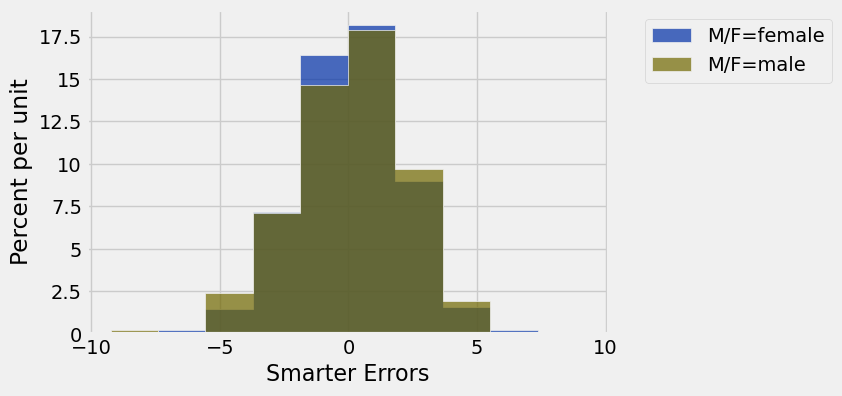

In [33]:
heights.hist('Smarter Errors', group='M/F')

## Grouping by One Column ##

In [34]:
cones = Table.read_table('cones.csv').drop('Color')
cones

Flavor,Price
strawberry,3.55
chocolate,4.75
chocolate,5.25
strawberry,5.25
chocolate,5.25
bubblegum,4.75


In [37]:
cones.group('Flavor')

Flavor,count
bubblegum,1
chocolate,3
strawberry,2


In [38]:
cones.group('Flavor', np.average)

Flavor,Price average
bubblegum,4.75
chocolate,5.08333
strawberry,4.4


In [39]:
cones.group('Flavor', np.min)

Flavor,Price min
bubblegum,4.75
chocolate,4.75
strawberry,3.55


In [40]:
cones.group('Flavor', list)

Flavor,Price list
bubblegum,[4.75]
chocolate,"[4.75, 5.25, 5.25]"
strawberry,"[3.5499999999999998, 5.25]"


## Grouping By One Column: Welcome Survey ##

In [43]:
survey = Table.read_table('welcome_survey_sp26.csv')
survey.show(3)

Year,Extroversion,Text Recipients,Sleep Hours,Handedness,Sleep Position,Piercings
1,5,1,8,Right-handed,On your back,2
2,8,20,6,Right-handed,On your right side,2
1,10,10,6,Left-handed,On your back,0


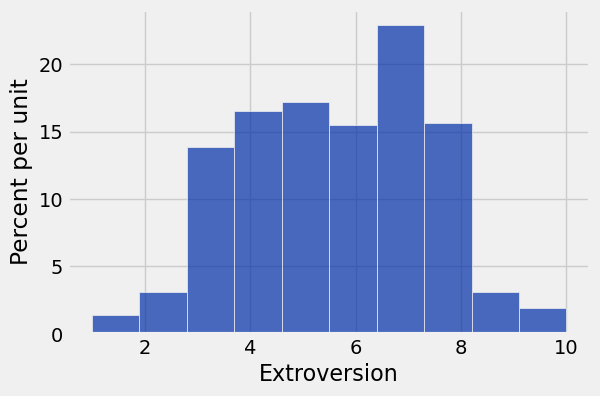

In [44]:
survey.hist('Extroversion')

In [50]:
survey.select(1, 2, 3).group('Extroversion', np.average)

Extroversion,Text Recipients average,Sleep Hours average
1,2.69231,7.26923
2,5.6,7.2
3,4.24812,7.03008
4,4.94969,7.12893
5,5.41212,7.10303
6,5.87919,7.11409
7,6.89091,7.09091
8,9.15333,7.16667
9,9.53333,7.4
10,14.3889,6.83333


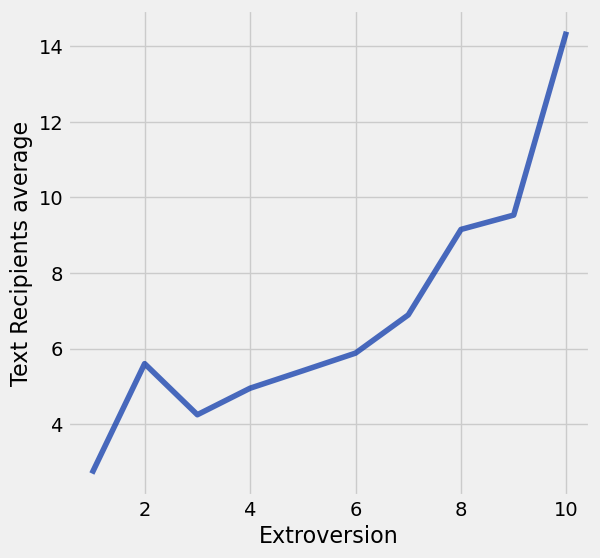

In [51]:
survey.group('Extroversion', np.average).plot('Extroversion', 'Text Recipients average')

In [52]:
survey.group("Year")

Year,count
1,572
2,207
3,203
4,71
5,14


In [53]:
(survey
 .select("Year", "Sleep Hours")
 .group("Year", np.average))

Year,Sleep Hours average
1,7.17692
2,7.05314
3,6.94236
4,7.21831
5,7.42857


## Lists

In [ ]:
[1, 5, 'hello', 5.0]

In [ ]:
[1, 5, 'hello', 5.0, make_array(1,2,3)]

## Grouping by Two Columns ##

Do right-handed people tend to sleep on their left side and left-handed people sleep on their right?

In [55]:
survey.group('Sleep Position')

Sleep Position,count
On your back,265
On your left side,273
On your right side,412
On your stomach,117


In [56]:
survey.group(['Handedness', 'Sleep Position']).show()

Handedness,Sleep Position,count
Left-handed,On your back,15
Left-handed,On your left side,20
Left-handed,On your right side,23
Left-handed,On your stomach,12
Right-handed,On your back,250
Right-handed,On your left side,251
Right-handed,On your right side,389
Right-handed,On your stomach,104
ambidextrous,On your left side,1
both,On your stomach,1
